In [1]:
# Ensure repository-root working directory after notebook relocation
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
repo_root = cwd
if not (repo_root / 'pyproject.toml').exists():
    for parent in [cwd, *cwd.parents]:
        if (parent / 'pyproject.toml').exists():
            repo_root = parent
            break
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print(f'Working directory: {repo_root}')


Working directory: /Users/almazgil/Desktop/projects/routecluster-benchmark


In [2]:
from aizynthfinder.interfaces import AiZynthApp
from cgr_clustering.aizynth_converter import (
    extract_routes_from_tree, 
    filter_unique_routes
)
from tqdm import tqdm
import pickle

### Routes Generation

In [3]:
smiles = 'N#CC1(c2ccc(NC(=O)c3cccnc3NCc3ccncc3)cc2)CCCC1' 

In [4]:
# Load the AiZynthFinder application
app = AiZynthApp("config.yml")

Loading template-based expansion policy model from ./data/uspto_model.onnx to uspto
Loading templates from ./data/uspto_templates.csv to uspto
Loading template-based expansion policy model from ./data/uspto_ringbreaker_model.onnx to ringbreaker
Loading templates from ./data/uspto_ringbreaker_templates.csv.gz to ringbreaker
Loading filter policy model from ./data/uspto_filter_model.onnx to uspto
Loading stock from InMemoryInchiKeyQuery to askcos


Text(value='', continuous_update=False, description='SMILES')

Output(layout=Layout(border_bottom='1px solid silver', border_left='1px solid silver', border_right='1px solid…

Output(layout=Layout(border_bottom='1px solid silver', border_left='1px solid silver', border_right='1px solid…

Output(layout=Layout(border_bottom='1px solid silver', border_left='1px solid silver', border_right='1px solid…

Output(layout=Layout(border_bottom='1px solid silver', border_left='1px solid silver', border_right='1px solid…

### --- Route Extraction and Filtering ---

In [5]:
route_collections = extract_routes_from_tree(app)
print(f"Extracted {len(route_collections)} route collections.")
filtered_route_collection = filter_unique_routes(route_collections)
print(f"Filtered to {len(filtered_route_collection)} unique routes.")

Extracted 712 route collections.
Filtered to 230 unique routes.


### --- RouteCGR and SB-CGRs ---

In [6]:
from cgr_clustering.aizynth_converter import extract_all_route_cgrs
from synplan.chem.reaction_routes.route_cgr import *

In [118]:
route_cgrs_dict = extract_all_route_cgrs(filtered_route_collection, check_trans_error=True)

230it [00:28,  7.94it/s]


In [119]:
sb_cgrs_dict = compose_all_sb_cgrs(route_cgrs_dict)

### Clustering by SB-CGR

In [120]:
from synplan.chem.reaction_routes.clustering import cluster_routes

sbp_clusters = cluster_routes(sb_cgrs_dict)
print("Number of SB groups:", len(sbp_clusters))

Number of SB groups: 17


In [121]:
for i, group in sbp_clusters.items():
    print(i)
    sb_cgr = group['sb_cgr']
    sb_cgr.clean2d()
    display(sb_cgr)
    print(group['route_ids'])

1.1


[111]
2.1


[76]
2.2


[0, 1, 4, 6, 8, 9, 12, 13, 14, 16, 18, 23, 24, 28, 29, 30, 31, 32, 33, 84, 100, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 127, 128, 129, 130, 131, 132, 133, 138, 139, 140, 141, 142, 143, 144, 145, 146, 150, 151, 152, 153, 154, 155, 156, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 210, 211, 212, 213, 214, 215, 216, 217, 219, 220, 221, 222, 223, 224, 225]
2.3


[173]
2.4


[11, 15, 25]
2.5


[2, 3, 5, 7, 10, 17, 22, 27, 125, 126, 136, 137, 169, 170, 171, 183, 184, 186, 187, 188, 189, 190, 195, 208, 209, 218, 226, 227, 228]
3.1


[89, 95, 97]
3.2


[20, 148, 196]
3.3


[108]
3.4


[19, 21, 26, 134, 135, 147, 149]
3.5


[172, 174, 175, 176, 191, 192, 193, 194, 229]
4.1


[73, 74, 75, 77, 78, 79, 80, 81, 82, 83, 88, 90, 91, 92, 94, 96, 98, 99, 101, 102, 103, 104, 105, 106, 157, 158, 159]
4.2


[107, 109, 110, 177, 178, 179]
4.3


[56, 58, 59, 60, 61, 62, 63, 180, 181, 182, 185]
4.4


[35, 38, 39, 40, 41, 42, 43, 48, 49, 50, 51, 55, 57, 70, 71, 72, 161, 162, 163, 165, 166, 167]
5.1


[34, 36, 37, 85, 86, 87, 93, 160]
5.2


[44, 45, 46, 47, 52, 53, 54, 64, 65, 66, 67, 68, 69, 164, 168]


### Results overlaping Comparison

In [ ]:
from collections import defaultdict

cluster_arr = filtered_route_collection.cluster(len(sbp_clusters))
clusters_ab = defaultdict(list)
for idx, val in enumerate(cluster_arr):
    clusters_ab[val+1].append(idx)

Adjusted Rand Index (ARI): 0.5838
Normalized Mutual Information (NMI): 0.8002
Entropy first: 2.1378
Entropy second: 2.1375
Mutual Information: 1.7105
Variation of Information (VI): 0.8541



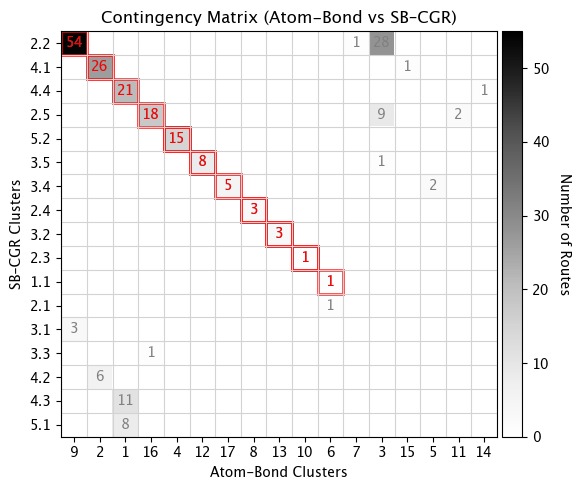

In [ ]:
from cgr_clustering.comparing import *
from cgr_clustering.visualization import display_contingency_matrix

y_true, y_pred = calculate_similarity_metrics(sbp_clusters, clusters_ab, print_stats=True)
cm = compute_contingency_matrix(y_true, y_pred)
matched, avg_jaccard = match_clusters(sbp_clusters, clusters_ab)
cm_sorted, matches = diagonalize_contingency(cm)
display_contingency_matrix(matches, cm_sorted, method='Atom-Bond')

In [23]:
avg_jaccard

0.5077150288087527

### Explore routes by IDs

Need to run image generetaion (might take a while)

In [10]:
images = filtered_route_collection.make_images()

Number of routes in cell 21
Routes ids in AiZynthFinder list [35, 38, 39, 40, 41, 42, 48, 49, 50, 51, 55, 57, 69, 70, 72, 162, 163, 164, 166, 167, 168]
ID: 35


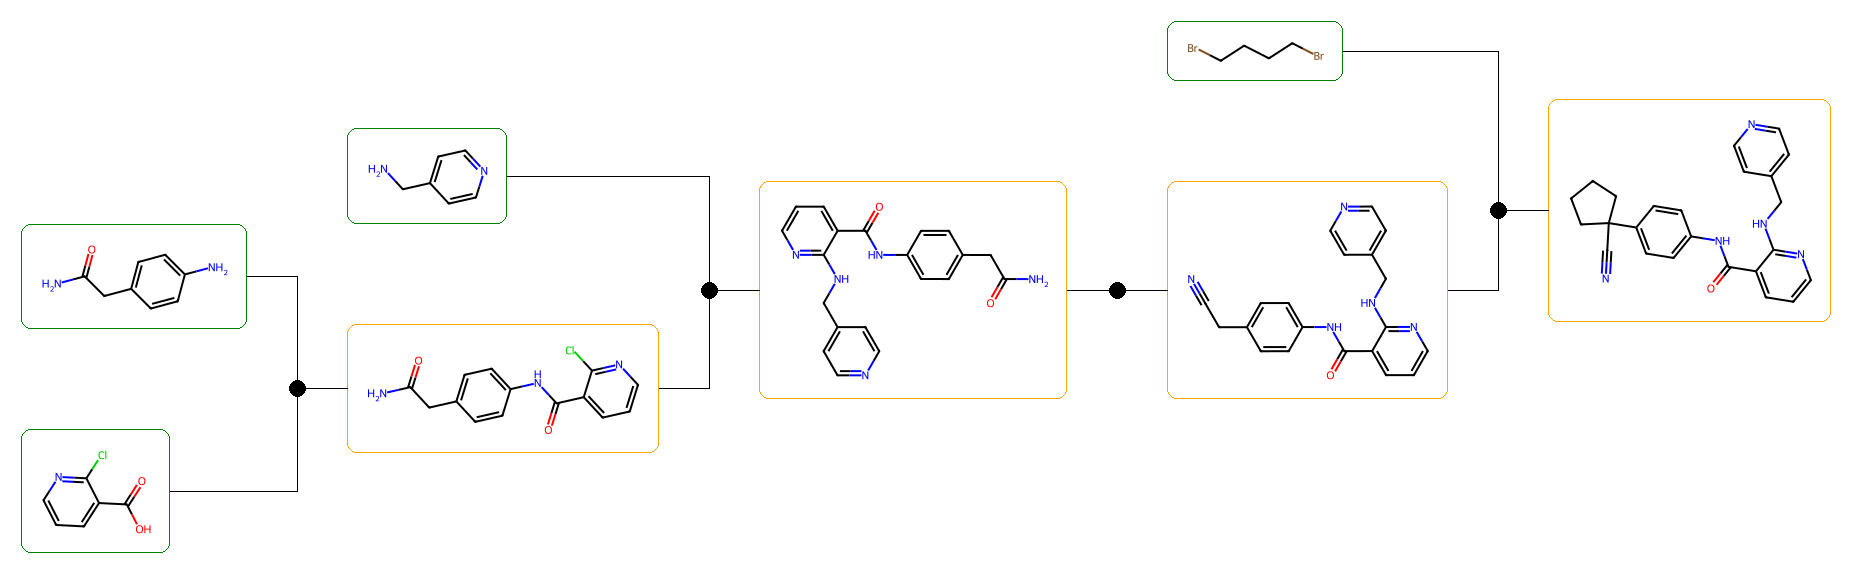

ID: 38


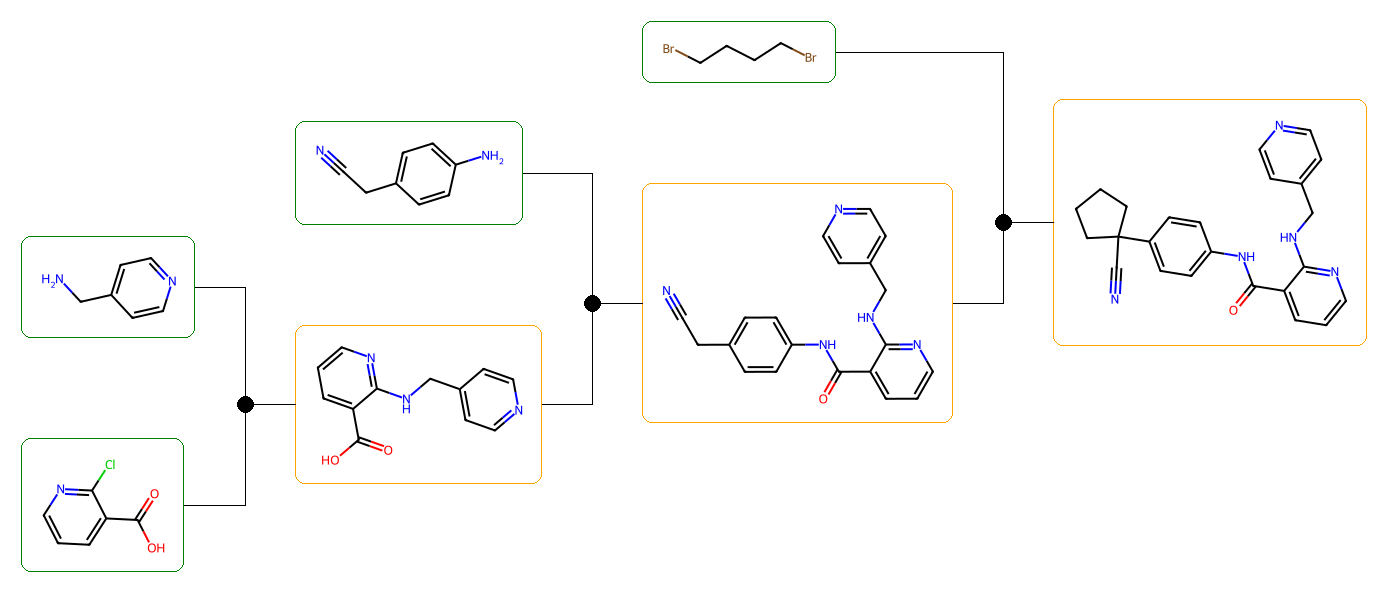

ID: 39


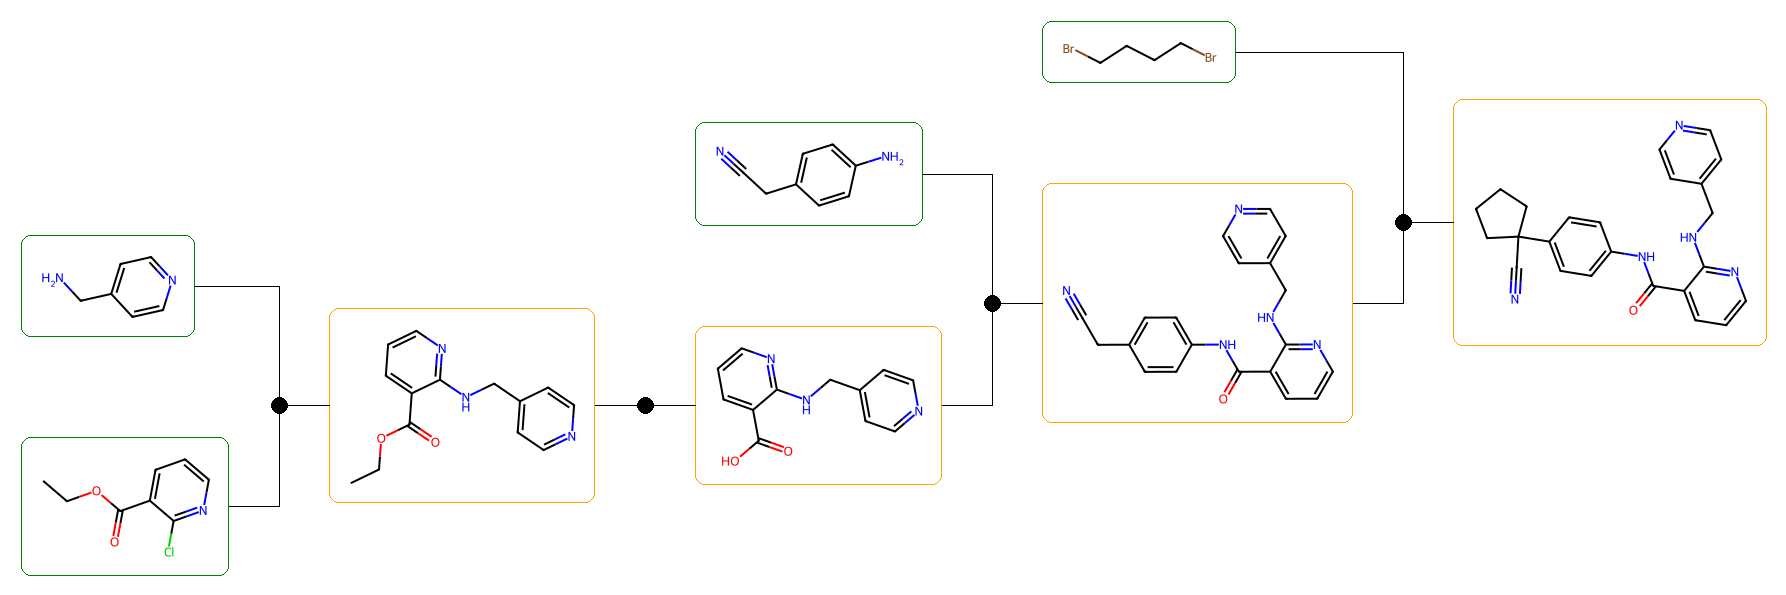

ID: 40


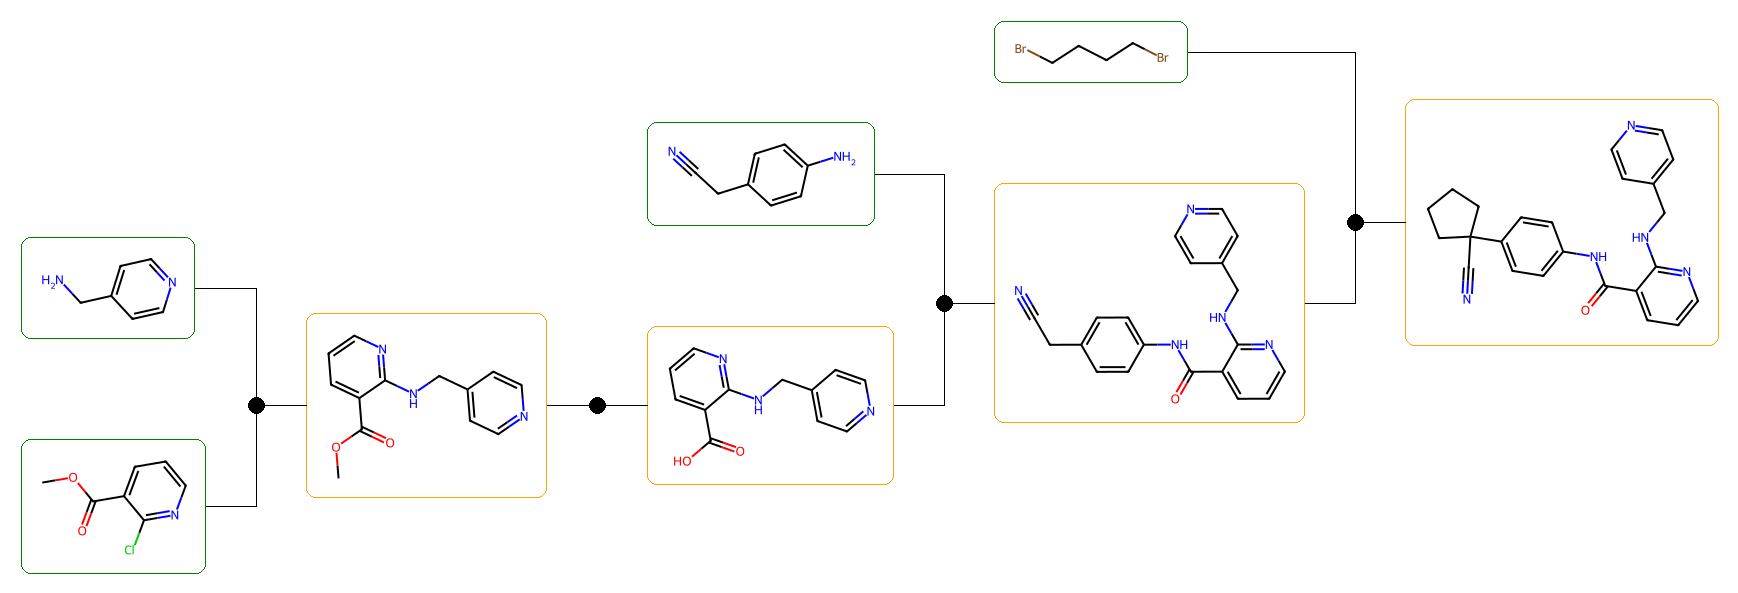

ID: 41


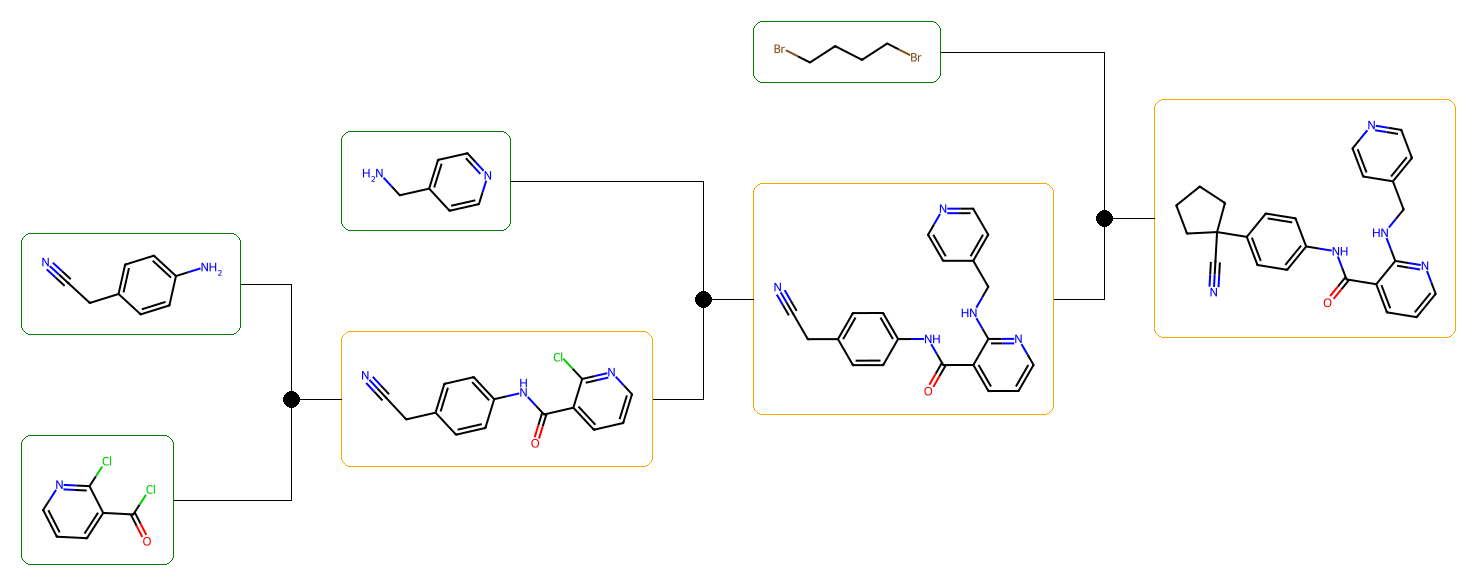

ID: 42


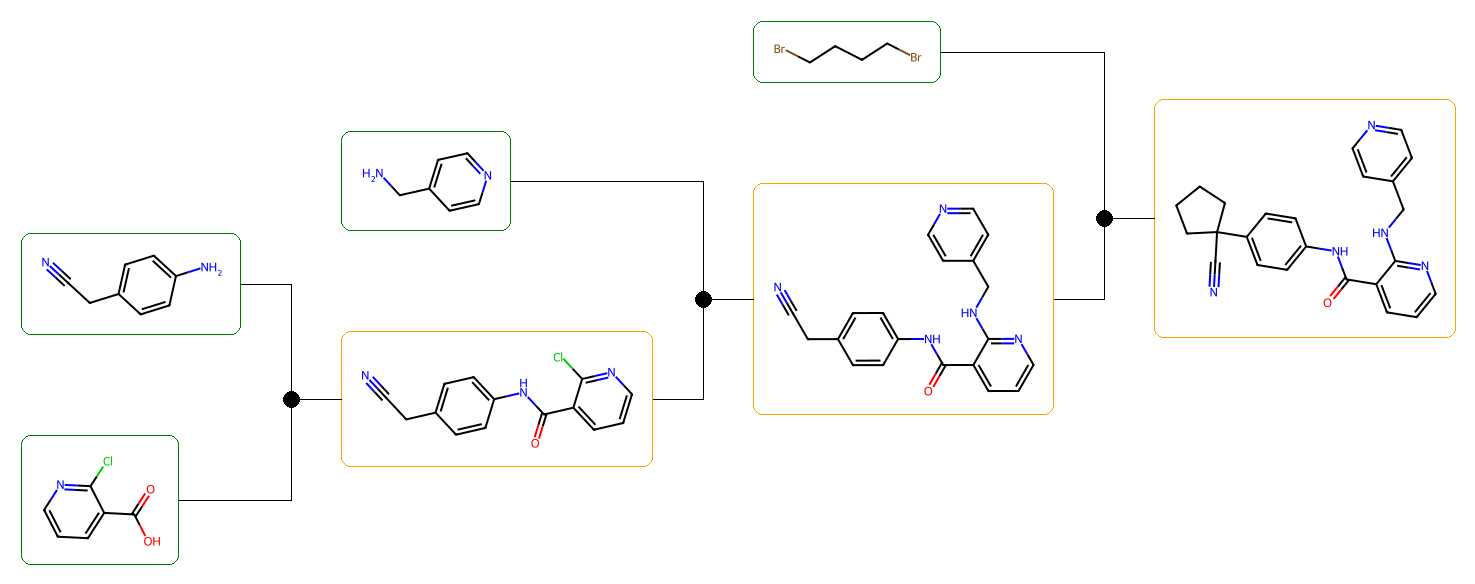

ID: 48


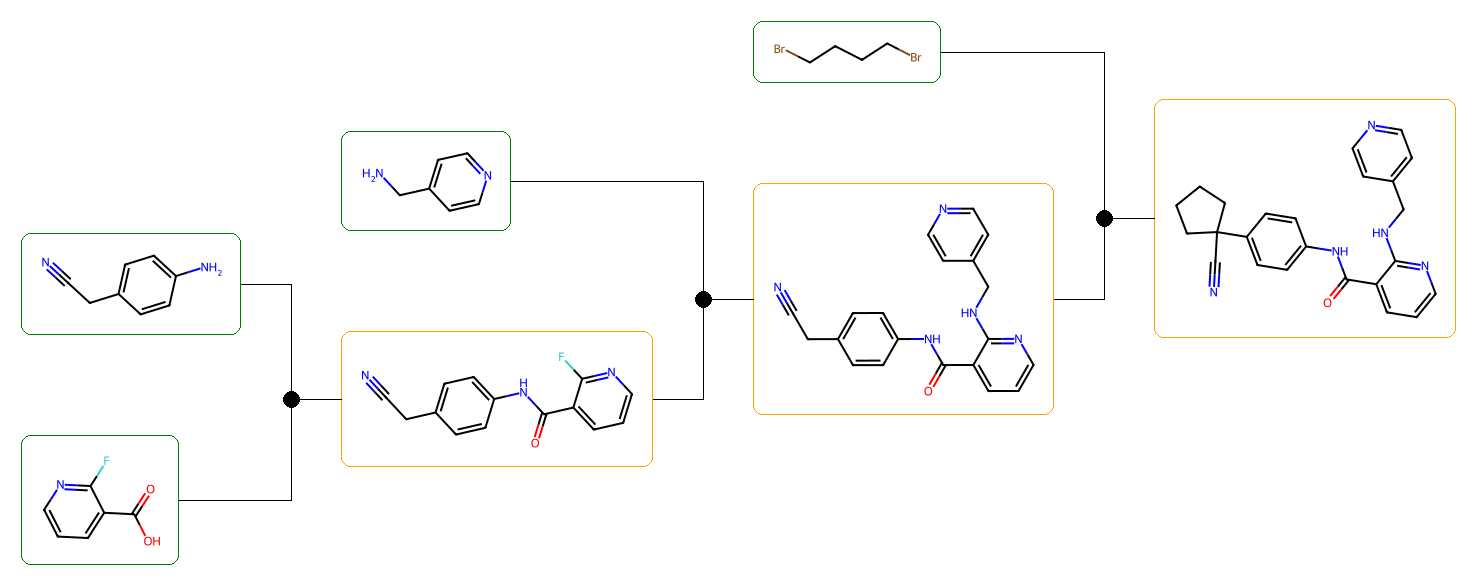

ID: 49


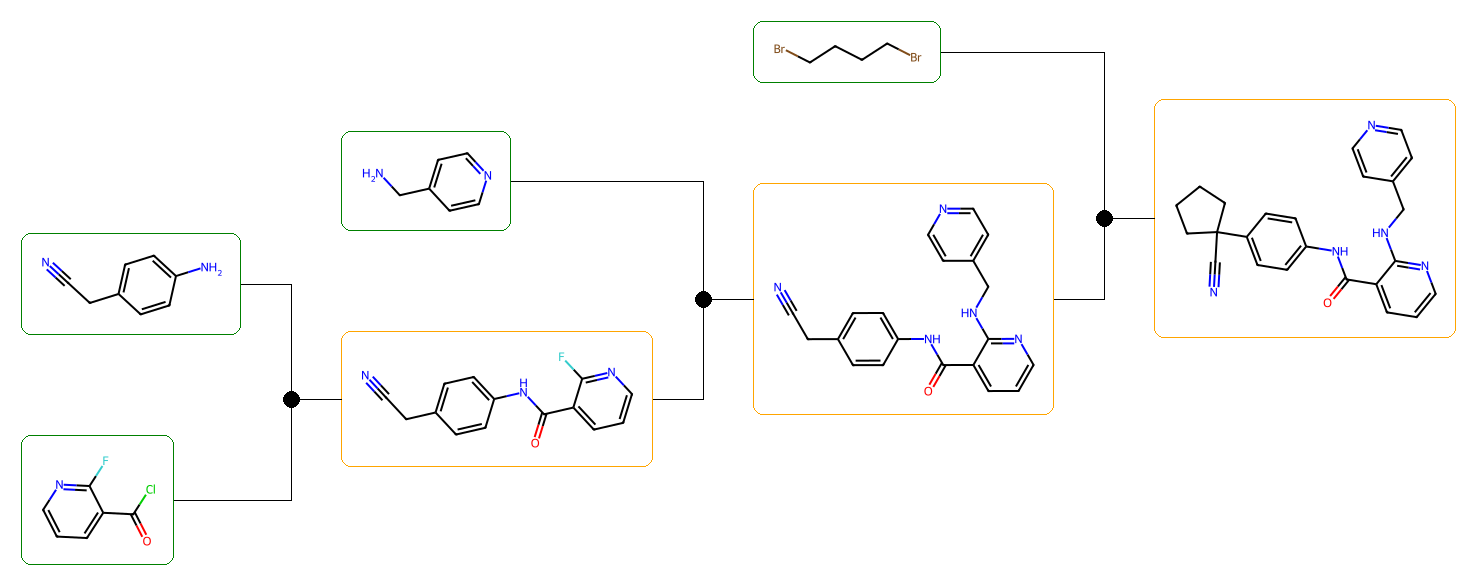

ID: 50


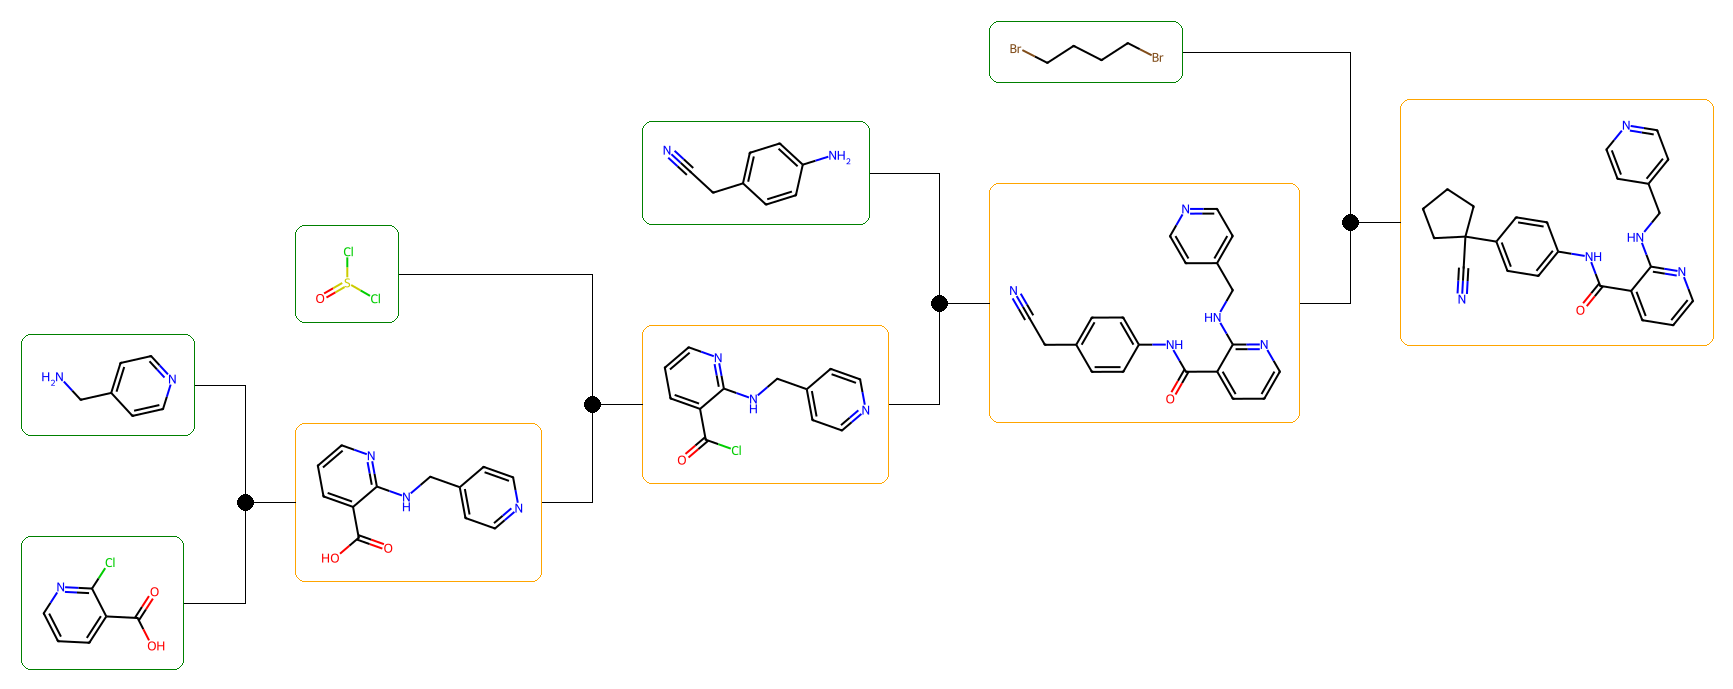

ID: 51


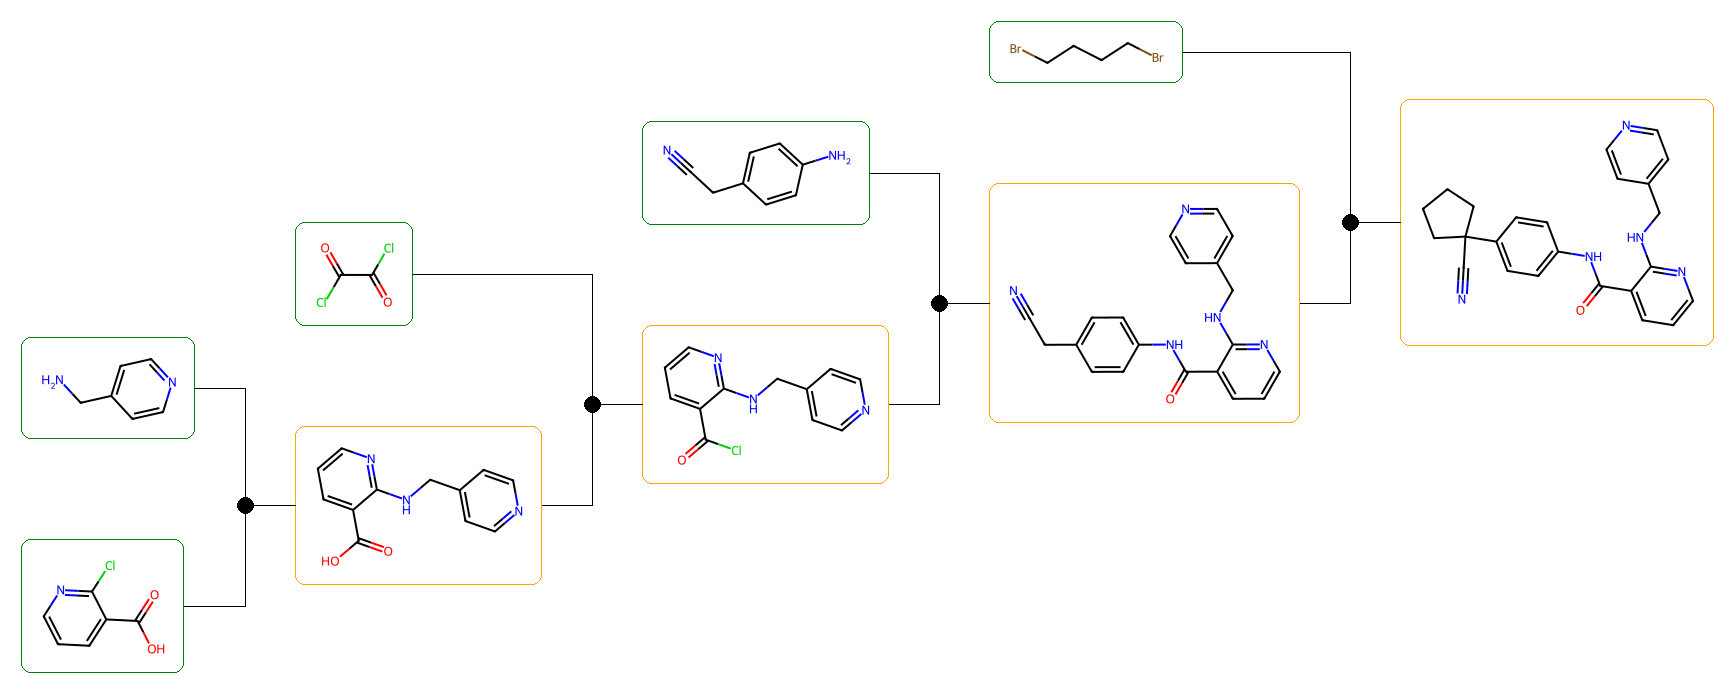

In [ ]:
from cgr_clustering.visualization import show_routes_in_cell

sb_cgr_ind = '4.4'
ab_ind = 1

show_routes_in_cell(sbp_clusters, clusters_ab, sb_cgr_ind, ab_ind, images, first_n=10)

Number of routes in cell 8
Routes ids in AiZynthFinder list [34, 36, 37, 85, 86, 87, 93, 161]
ID: 34


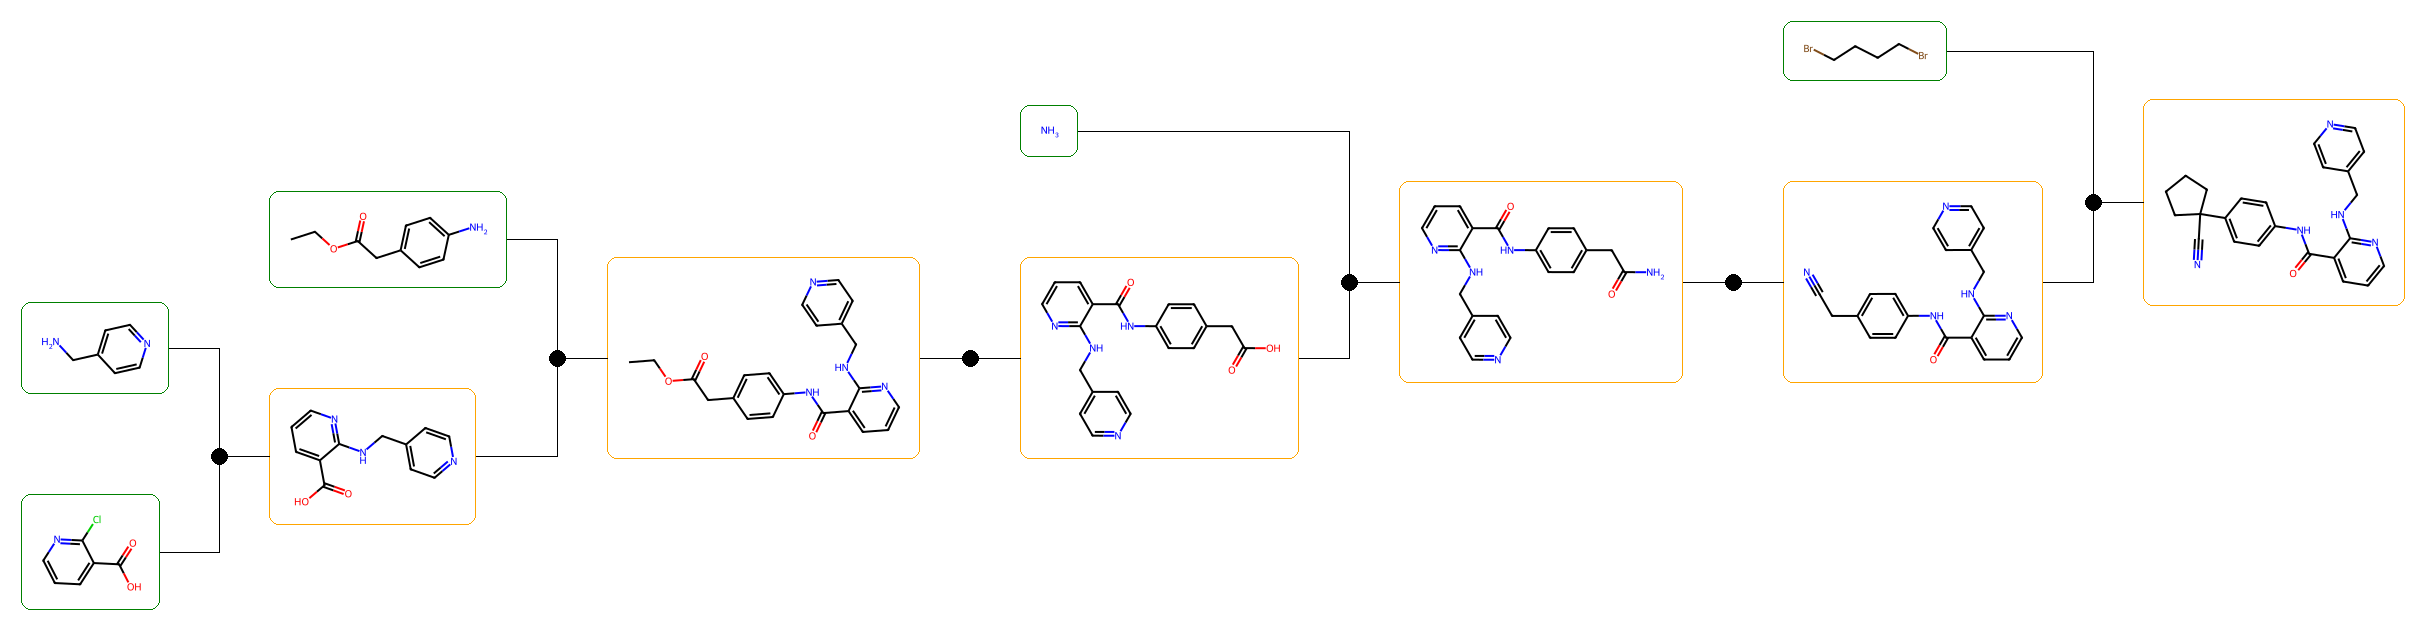

ID: 36


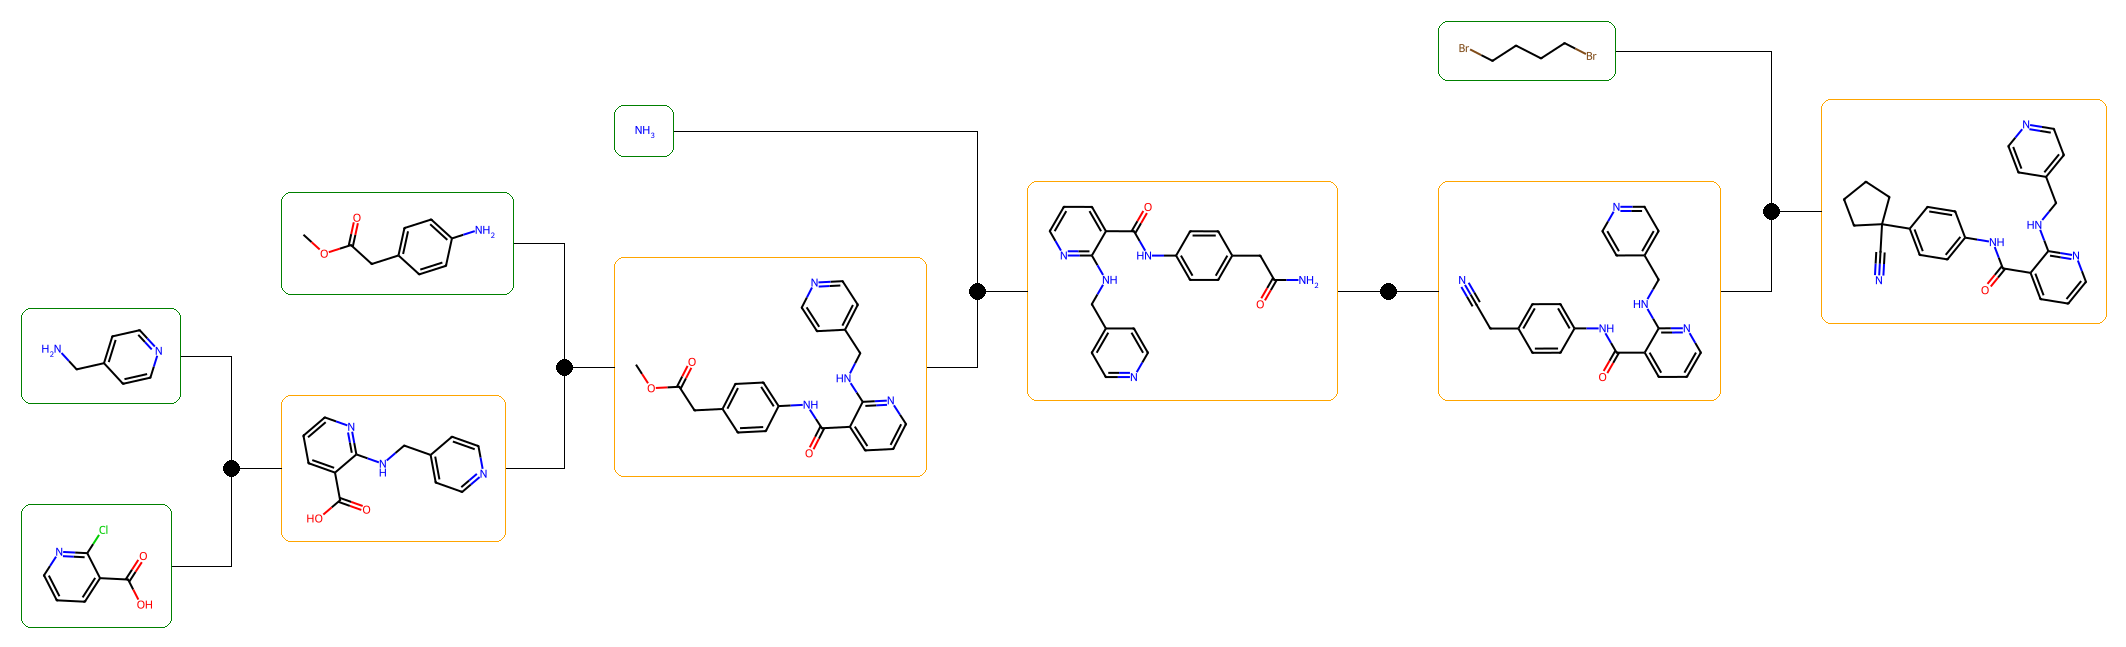

ID: 37


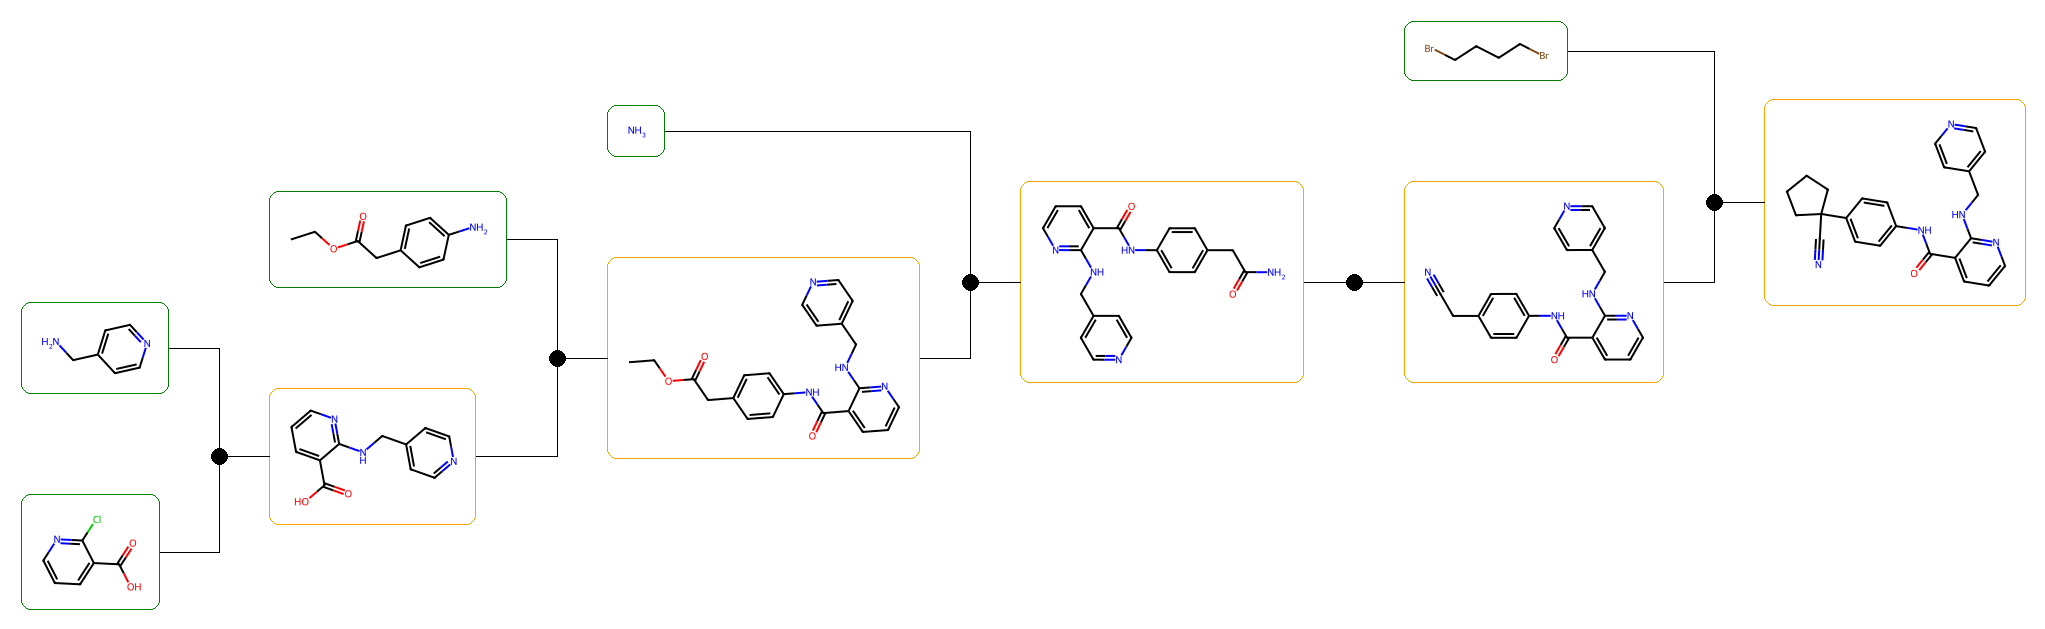

ID: 85


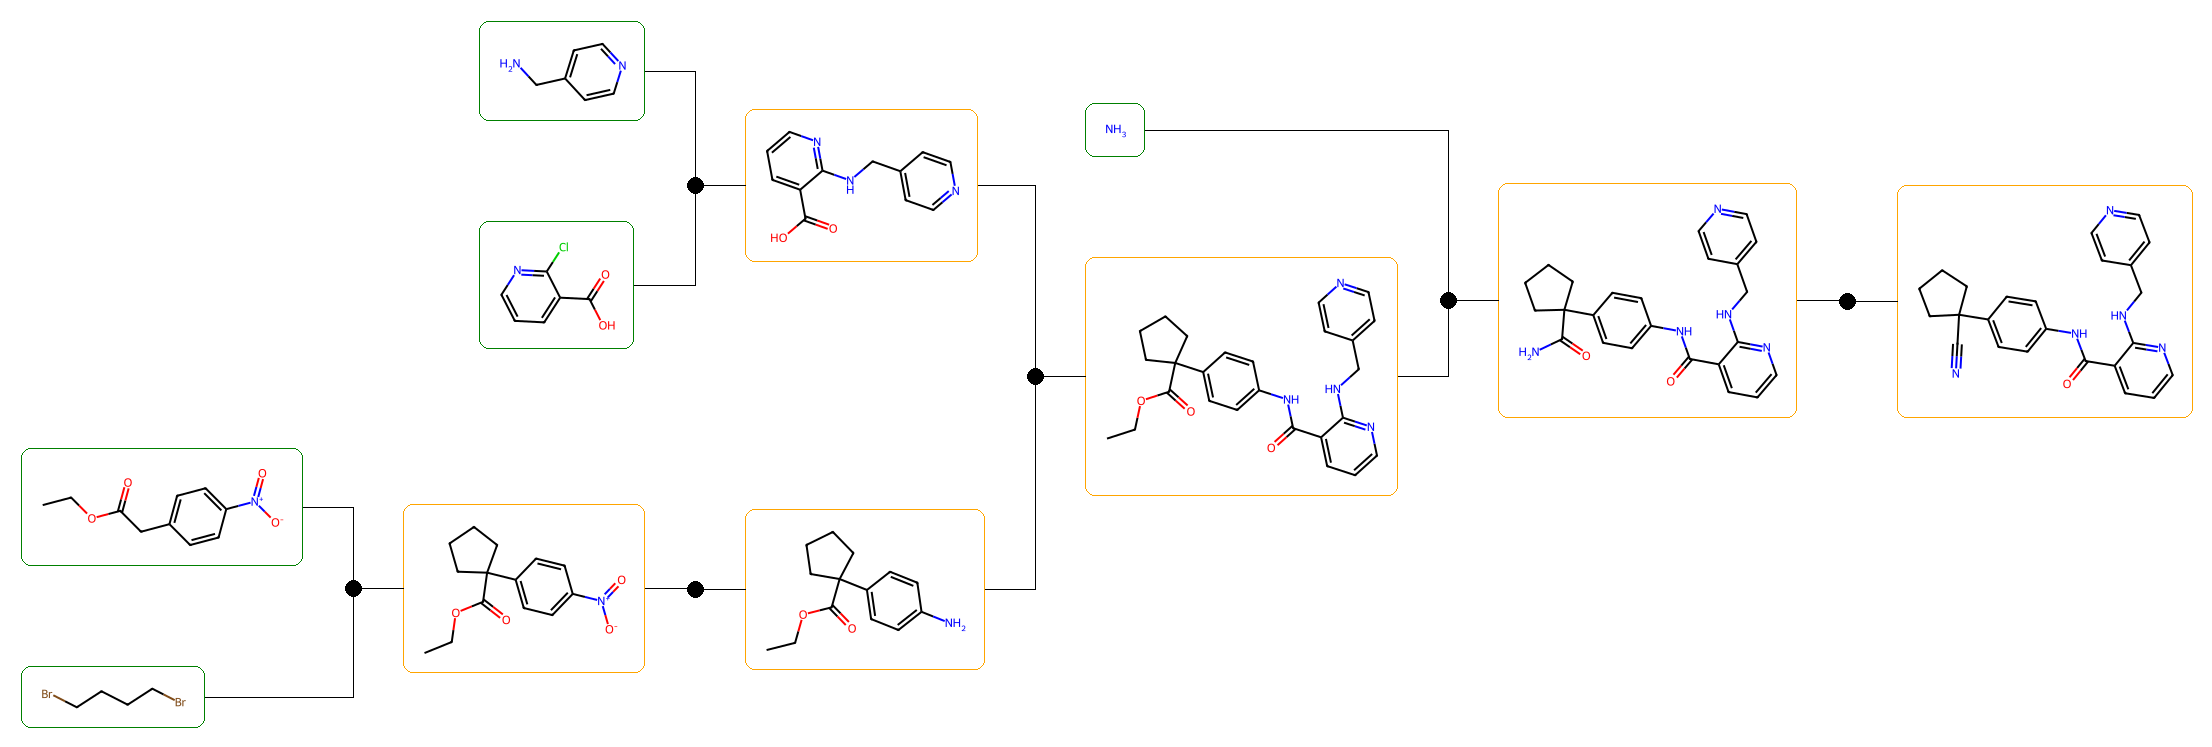

ID: 86


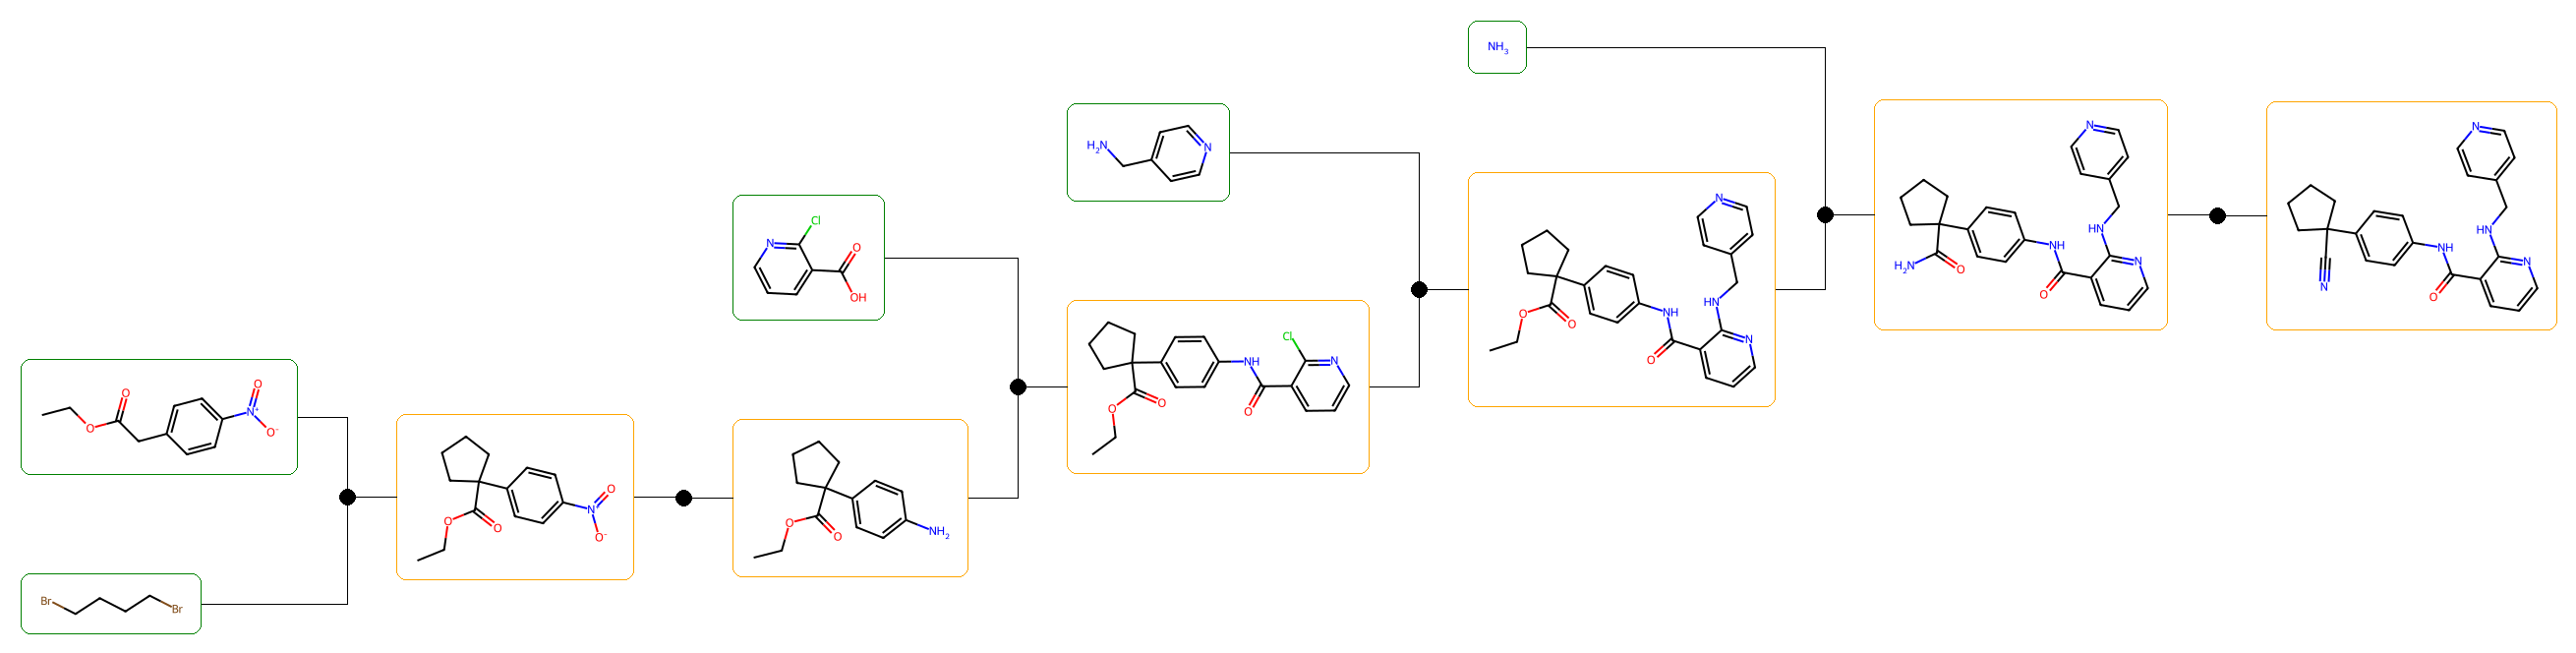

ID: 87


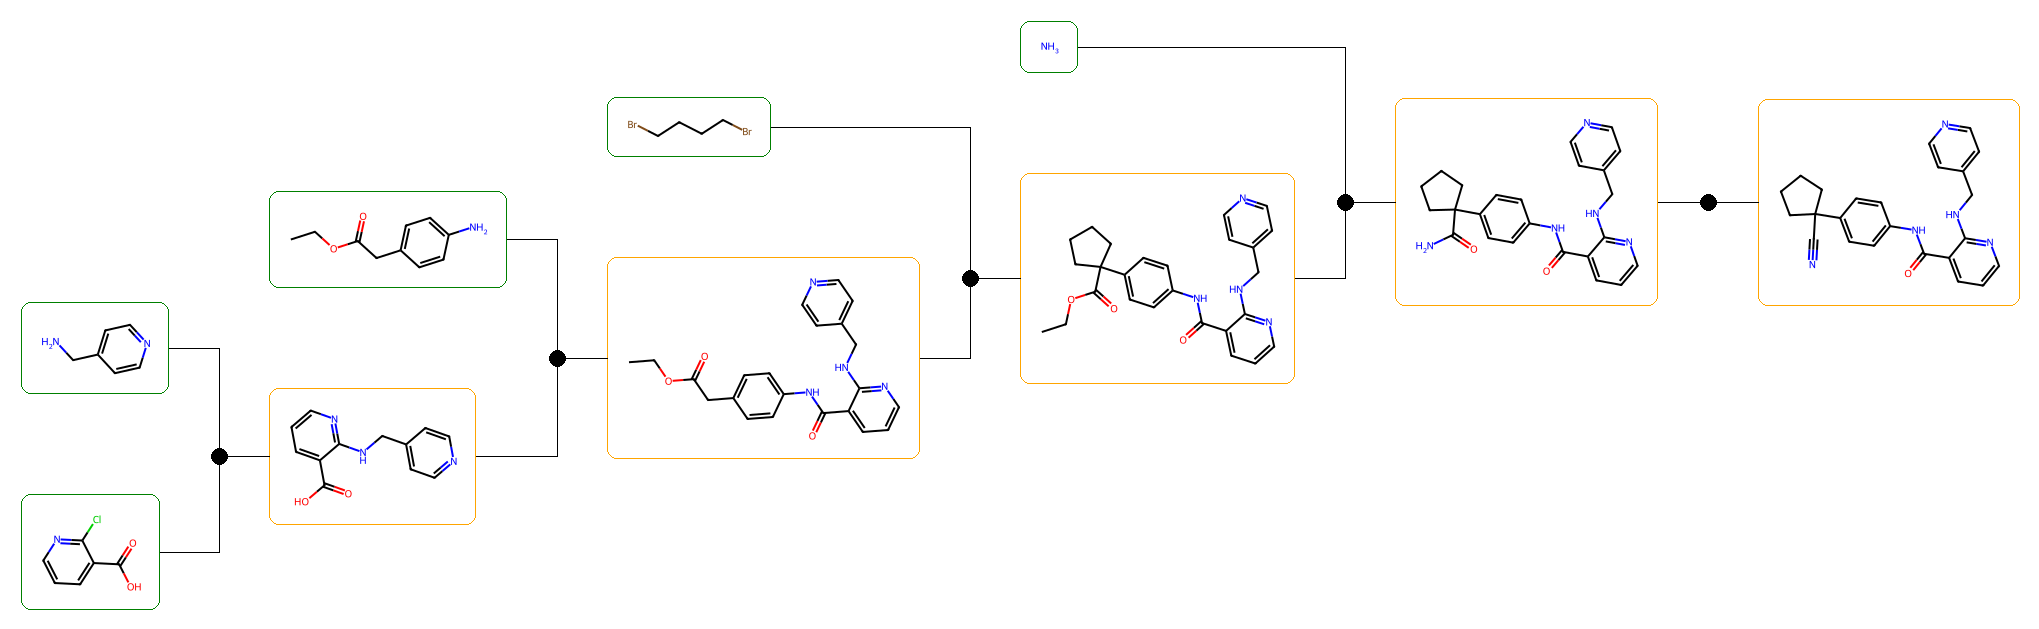

ID: 93


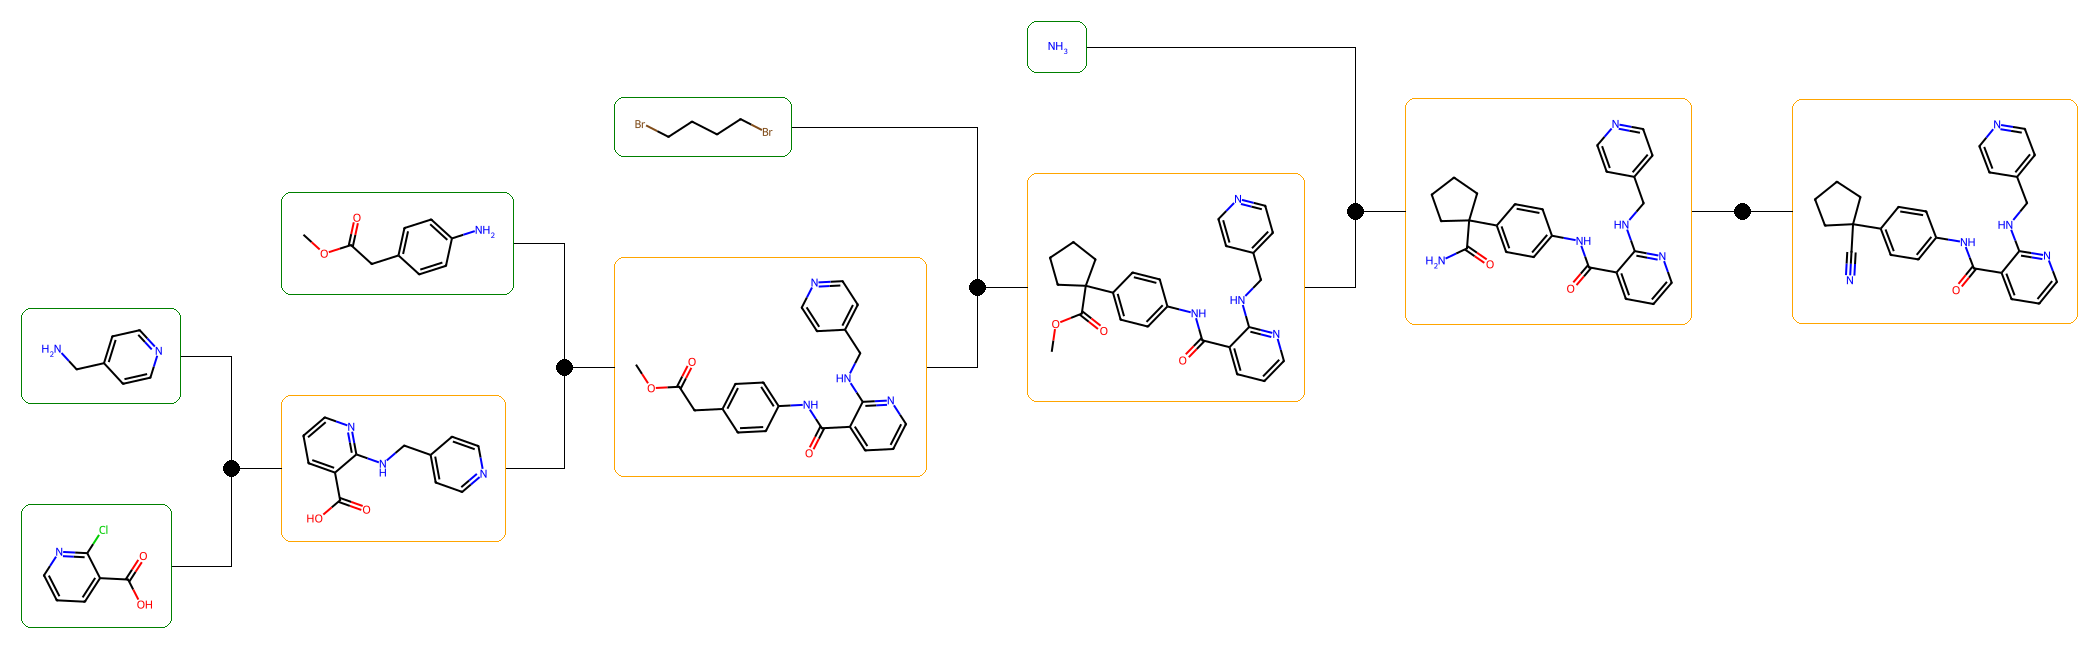

ID: 161


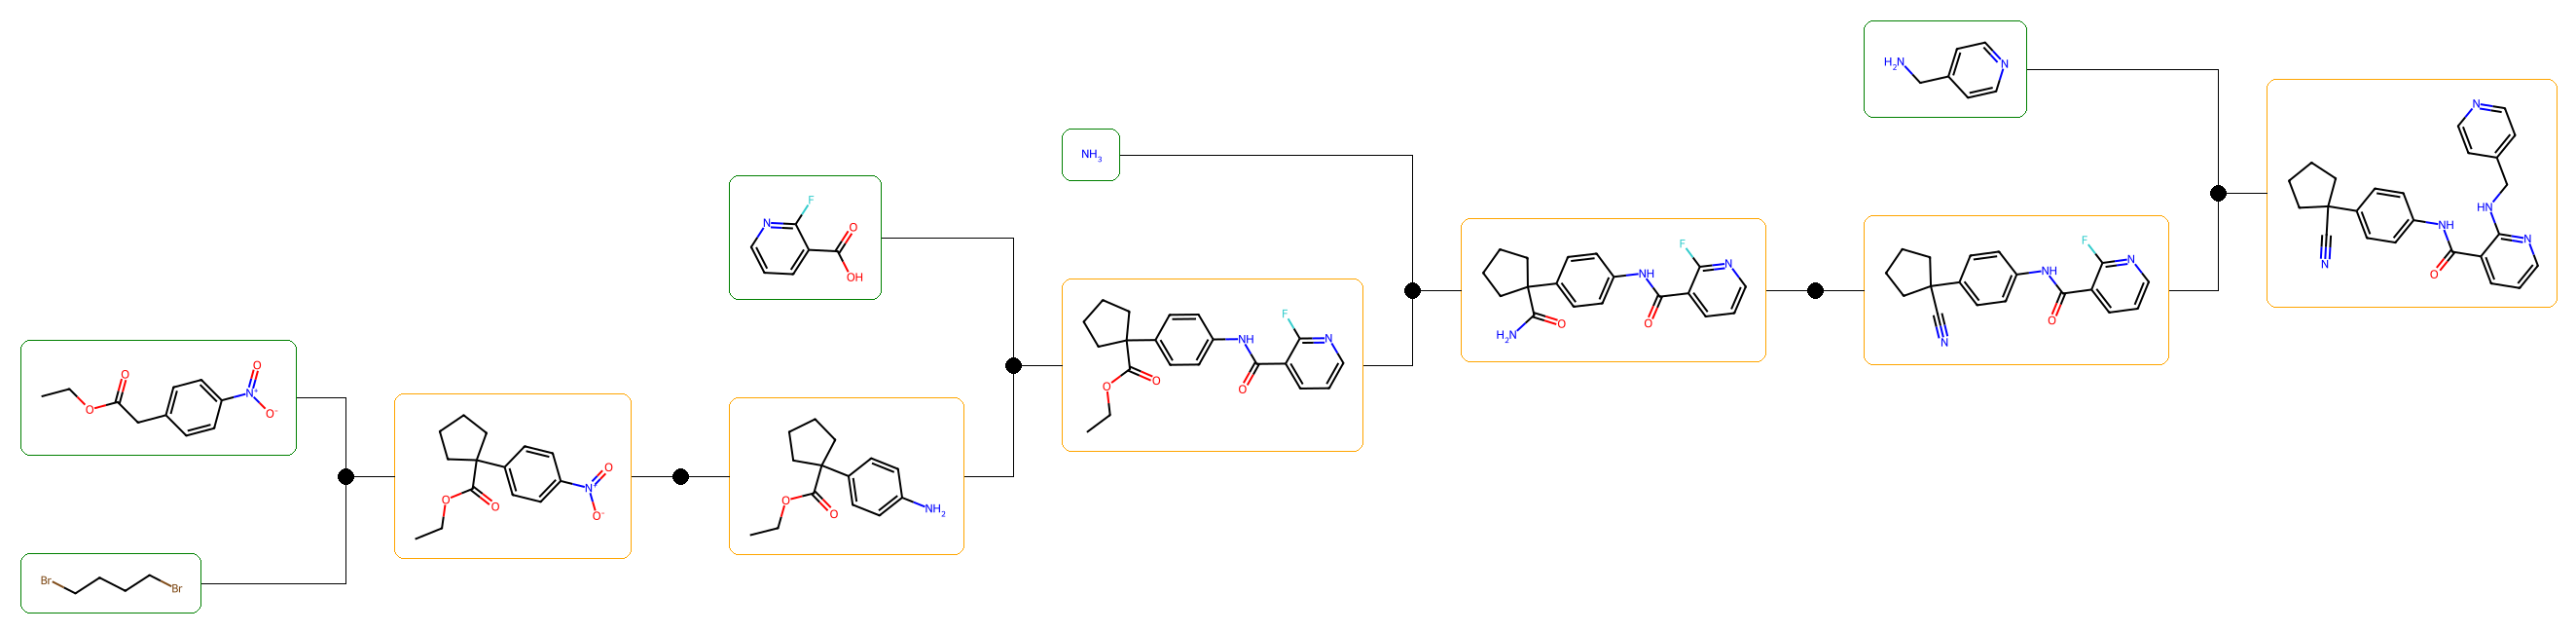

In [ ]:
sb_cgr_ind = '5.1'
ab_ind = 1
# show_routes_in_cell(sb_cgr_ind, ab_ind)
show_routes_in_cell(sbp_clusters, clusters_ab, sb_cgr_ind, ab_ind, images, first_n=10)

In [ ]:
sb_cgr_ind = '2.2'
ab_ind = 9

show_routes_in_cell(sb_cgr_ind, ab_ind, first_n=10)

### For inter-comparison with other retorysnthteic tools' results (SynPlanner and ASKCOS)

In [ ]:
pickle.dump(sbp_clusters, open('./inter_comp_data/aizynth_clusters.pkl', 'wb'))

NameError: name 'pickle' is not defined

In [18]:
ab_dist_matrix = filtered_route_collection.distance_matrix()
ab_dist_matrix

array([[0.        , 0.        , 0.31169379, ..., 0.62424882, 0.58486051,
        0.47123594],
       [0.        , 0.        , 0.30979069, ..., 0.62232825, 0.58248778,
        0.46851363],
       [0.31169379, 0.30979069, 0.        , ..., 0.44670357, 0.38765961,
        0.46402408],
       ...,
       [0.62424882, 0.62232825, 0.44670357, ..., 0.        , 0.15584063,
        0.16422035],
       [0.58486051, 0.58248778, 0.38765961, ..., 0.15584063, 0.        ,
        0.16464632],
       [0.47123594, 0.46851363, 0.46402408, ..., 0.16422035, 0.16464632,
        0.        ]], shape=(230, 230))

In [33]:
from cgr_clustering.utils import distance_matrix
    
sb_cgr_dist_matrix = distance_matrix(sb_cgrs_dict, radius=2, length=4096)
# route_cgr_dist_matrix = distance_matrix(route_cgrs_dict, radius=2, length=4096)
sb_cgr_dist_matrix

,0,1,2,3,4,5,6,7,8,9,...,220,221,222,223,224,225,226,227,228,229
0,0.000000,0.000000,0.210526,0.210526,0.000000,0.210526,0.000000,0.210526,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.210526,0.210526,0.210526,0.157895
1,0.000000,0.000000,0.210526,0.210526,0.000000,0.210526,0.000000,0.210526,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.210526,0.210526,0.210526,0.157895
2,0.210526,0.210526,0.000000,0.000000,0.210526,0.000000,0.210526,0.000000,0.210526,0.210526,...,0.210526,0.210526,0.210526,0.210526,0.210526,0.210526,0.000000,0.000000,0.000000,0.157895
3,0.210526,0.210526,0.000000,0.000000,0.210526,0.000000,0.210526,0.000000,0.210526,0.210526,...,0.210526,0.210526,0.210526,0.210526,0.210526,0.210526,0.000000,0.000000,0.000000,0.157895
4,0.000000,0.000000,0.210526,0.210526,0.000000,0.210526,0.000000,0.210526,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.210526,0.210526,0.210526,0.157895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,0.000000,0.000000,0.210526,0.210526,0.000000,0.210526,0.000000,0.210526,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.210526,0.210526,0.210526,0.157895
226,0.210526,0.210526,0.000000,0.000000,0.210526,0.000000,0.210526,0.000000,0.210526,0.210526,...,0.210526,0.210526,0.210526,0.210526,0.210526,0.210526,0.000000,0.000000,0.000000,0.157895
227,0.210526,0.210526,0.000000,0.000000,0.210526,0.000000,0.210526,0.000000,0.210526,0.210526,...,0.210526,0.210526,0.210526,0.210526,0.210526,0.210526,0.000000,0.000000,0.000000,0.157895
228,0.210526,0.210526,0.000000,0.000000,0.210526,0.000000,0.210526,0.000000,0.210526,0.210526,...,0.210526,0.210526,0.210526,0.210526,0.210526,0.210526,0.000000,0.000000,0.000000,0.157895


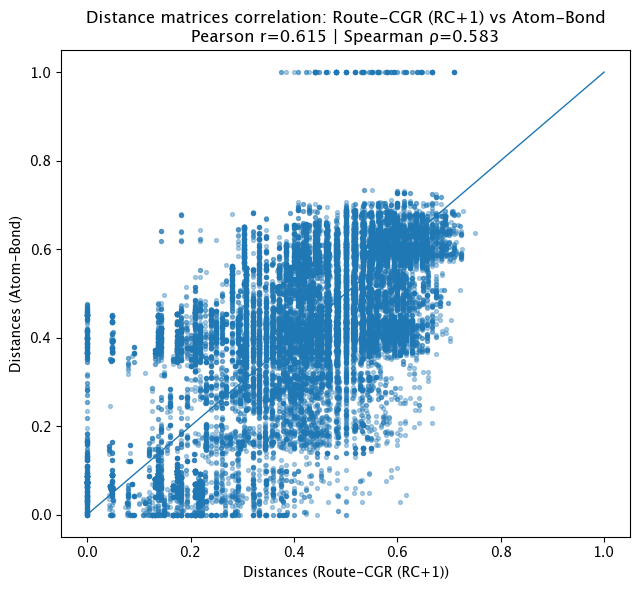

{'pearson_r': 0.6154798854261311, 'spearman_rho': 0.5831587347852133, 'n_pairs': 26335}


In [ ]:
from cgr_clustering.visualization import plot_distance_matrix_correlation

stats = plot_distance_matrix_correlation(sb_cgr_dist_matrix, ab_dist_matrix, method_1 = "SB-CGR (RC+1)", method_2 = "Atom-Bond")
print(stats)


In [ ]:
stats = plot_distance_matrix_correlation(route_cgr_dist_matrix, ab_dist_matrix, method_1 = "Route-CGR (RC+1)", method_2 = "Atom-Bond")
print(stats)

/Users/almazgil/Desktop/projects/routecluster-benchmark/cgr_clustering/visualization_multi_radius.py
(sb_cgrs_dict, ab_dist_matrix, poss_radii=(2, 3, 4), length=4096, bins=80, smooth_sigma_bins=3.0, sb_fill_alpha=0.6, ab_fill_alpha=0.2, sb_dotted_lines=False, sb_line_style=':', title_1='SB-CGR', title_2='ABS')


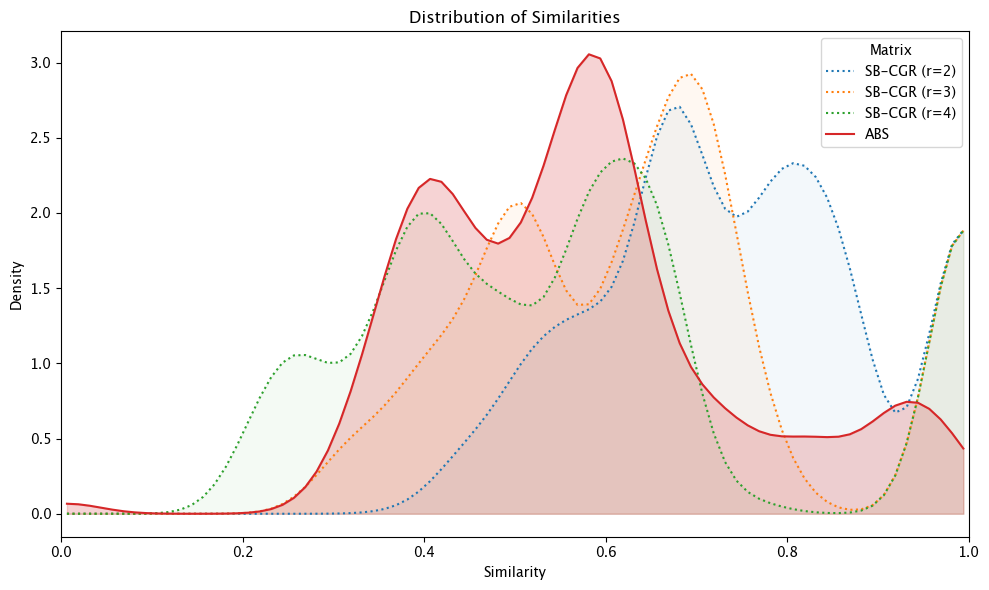

In [51]:
import importlib
import inspect
import cgr_clustering.visualization_multi_radius as vmr

importlib.reload(vmr)
print(vmr.__file__)
print(inspect.signature(vmr.plot_tanimoto_similarity_distributions_by_radius))

diff_sb_cgr_dists = vmr.plot_tanimoto_similarity_distributions_by_radius(
    sb_cgrs_dict,
    ab_dist_matrix,
    poss_radii=[2, 3, 4],
    sb_dotted_lines=True,   # optional
    sb_fill_alpha=0.05,
)


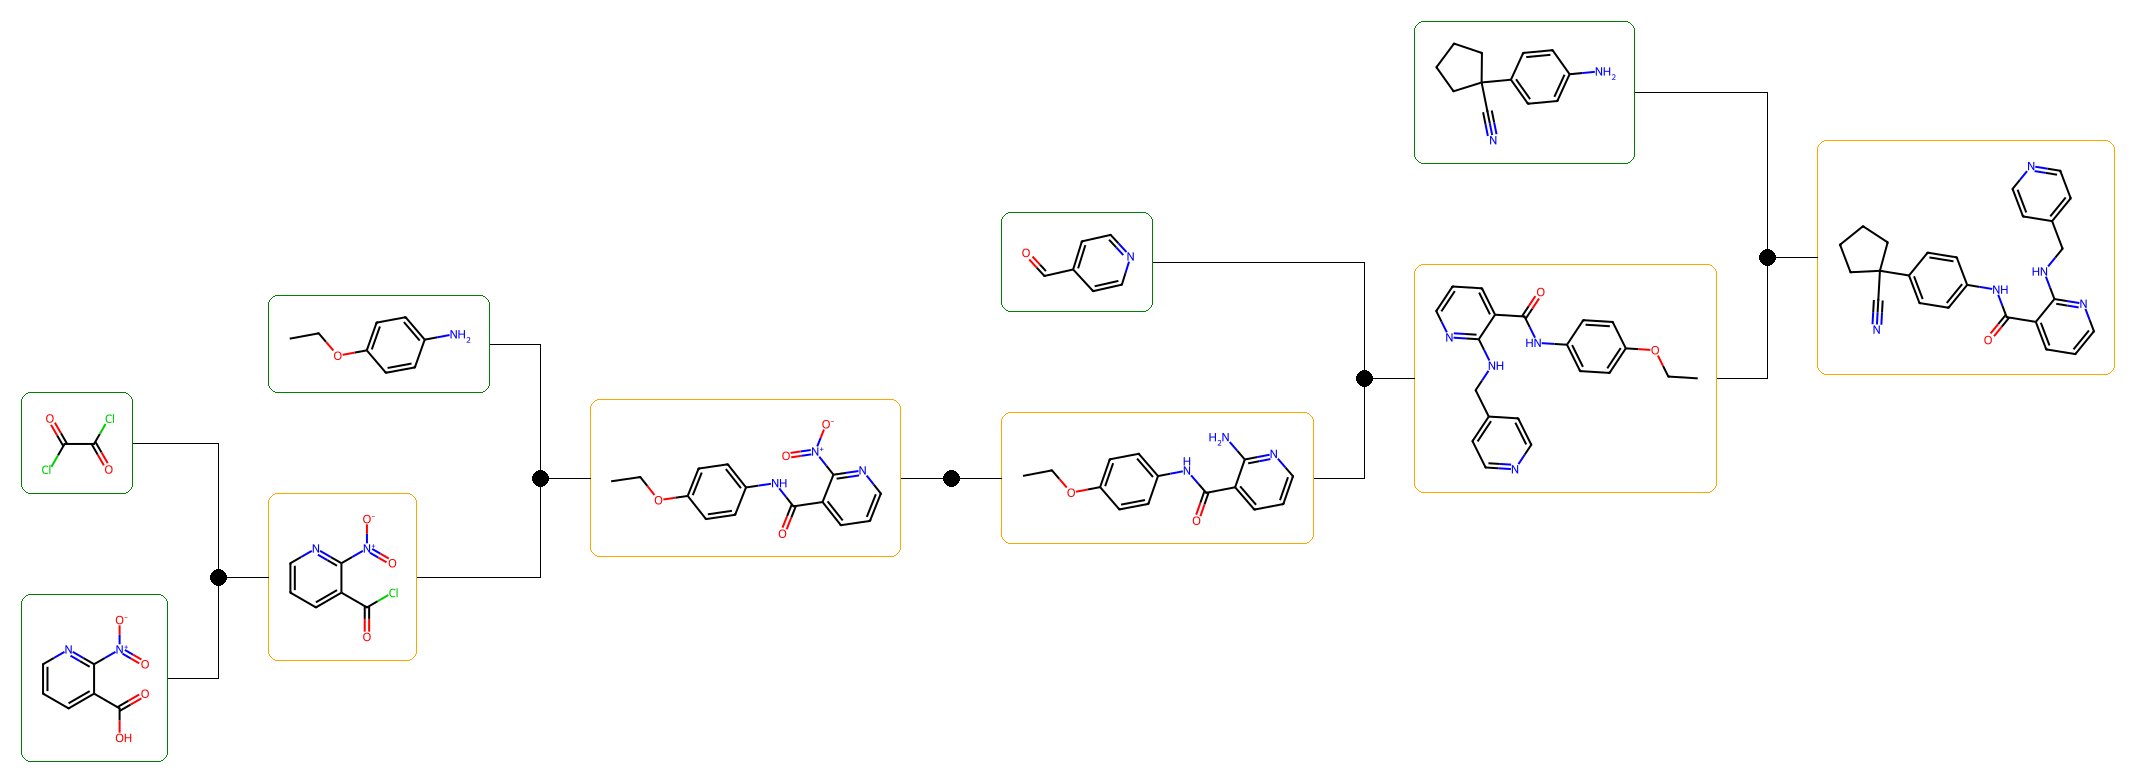

In [114]:
images[228]

# Transamidation error

In [ ]:
route_cgrs_dict = extract_all_route_cgrs(filtered_route_collection, check_trans_error=False)

In [ ]:
sb_cgrs_dict = compose_all_sb_cgrs(route_cgrs_dict)

In [ ]:
from synplan.chem.reaction_routes.clustering import cluster_routes

sbp_clusters = cluster_routes(sb_cgrs_dict)
print("Number of SB groups:", len(sbp_clusters))

In [115]:
from synplan.chem.reaction_routes.visualisation import cgr_display
wrong_cgr = route_cgrs_dict[228]
wrong_cgr.clean2d()
wrong_cgr

In [116]:
from synplan.chem.reaction_routes.visualisation import cgr_display
wrong_cgr = sb_cgrs_dict[228]
wrong_cgr.clean2d()
wrong_cgr

In [107]:
from CGRtools import smiles

d = smiles('CCOc1ccc(N)cc1')
d.clean2d()
d